In [1]:
import pandas as pd
import sqlite3

In [67]:


df = pd.read_csv("../data/shopping_trends_updated.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [68]:
conn = sqlite3.connect("../shopping.db")

df.to_sql(
    "shopping_trends",
    conn,
    if_exists="replace",
    index=False
)

print("Database Created Successfully!")

Database Created Successfully!


In [69]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../shopping.db")

pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,shopping_trends


In [70]:
df.columns.tolist()

['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Shipping Type',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Payment Method',
 'Frequency of Purchases']

In [71]:
pd.read_sql(
    "PRAGMA table_info(shopping_trends);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,Customer ID,INTEGER,0,None,0
1,1,Age,INTEGER,0,None,0
2,2,Gender,TEXT,0,None,0
3,3,Item Purchased,TEXT,0,None,0
4,4,Category,TEXT,0,None,0
5,5,Purchase Amount (USD),INTEGER,0,None,0
6,6,Location,TEXT,0,None,0
7,7,Size,TEXT,0,None,0
8,8,Color,TEXT,0,None,0
9,9,Season,TEXT,0,None,0


In [72]:
query = """
SELECT
Category,
SUM([Purchase Amount (USD)]) AS Revenue
FROM shopping_trends
GROUP BY Category
ORDER BY Revenue DESC;
"""

category_revenue = pd.read_sql(query, conn)
category_revenue

,Category,Revenue
0,Clothing,104264
1,Accessories,74200
2,Footwear,36093
3,Outerwear,18524


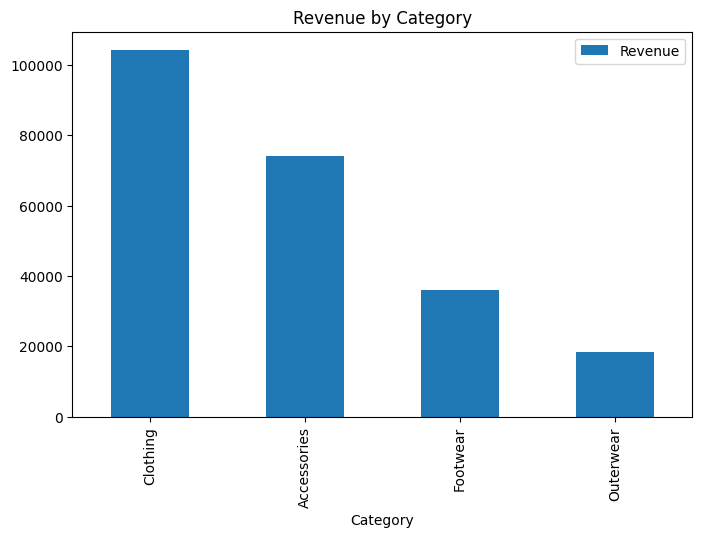

In [73]:
query = """
SELECT Category,
SUM([Purchase Amount (USD)]) AS Revenue
FROM shopping_trends
GROUP BY Category
ORDER BY Revenue DESC
"""

df_cat = pd.read_sql(query, conn)

df_cat.plot(
    x="Category",
    y="Revenue",
    kind="bar",
    figsize=(8,5),
    title="Revenue by Category"
)
plt.show()


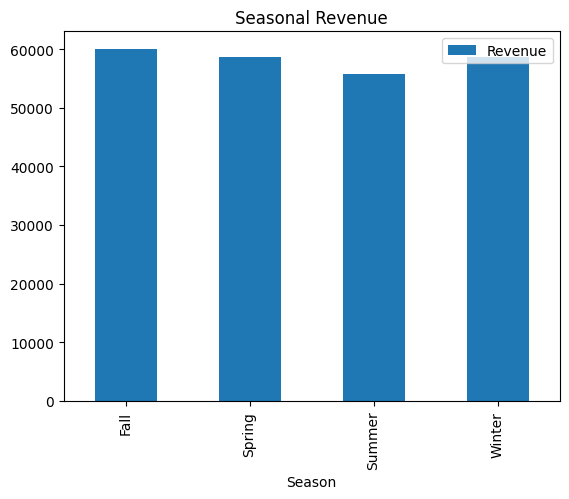

In [74]:
query = """
SELECT Season,
SUM([Purchase Amount (USD)]) AS Revenue
FROM shopping_trends
GROUP BY Season
"""

df_season = pd.read_sql(query, conn)

df_season.plot(
    x="Season",
    y="Revenue",
    kind="bar",
    title="Seasonal Revenue"
)
plt.show()

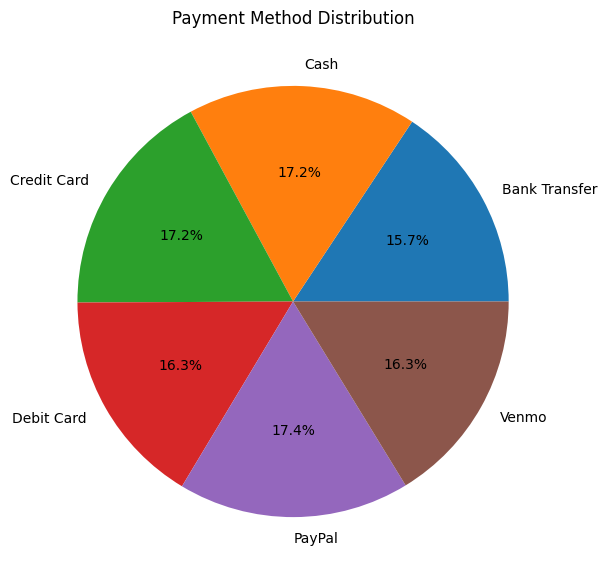

In [75]:
query = """
SELECT [Payment Method],
COUNT(*) AS Count
FROM shopping_trends
GROUP BY [Payment Method]
"""

df_pay = pd.read_sql(query, conn)

plt.figure(figsize=(7,7))
plt.pie(
    df_pay["Count"],
    labels=df_pay["Payment Method"],
    autopct="%1.1f%%"
)
plt.title("Payment Method Distribution")
plt.show()

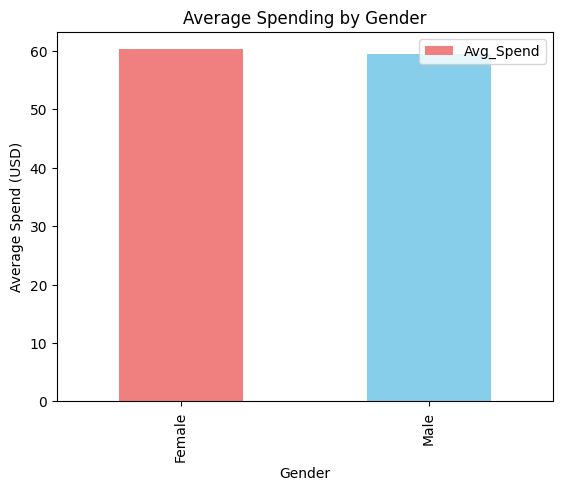

In [76]:
query = """
SELECT Gender,
AVG([Purchase Amount (USD)]) AS Avg_Spend
FROM shopping_trends
GROUP BY Gender
"""

df_gender = pd.read_sql(query, conn)

df_gender.plot(
    x="Gender",
    y="Avg_Spend",
    ylabel="Average Spend (USD)",
    kind="bar",
    color=["lightcoral", "skyblue"],
    title="Average Spending by Gender"
)
plt.show()

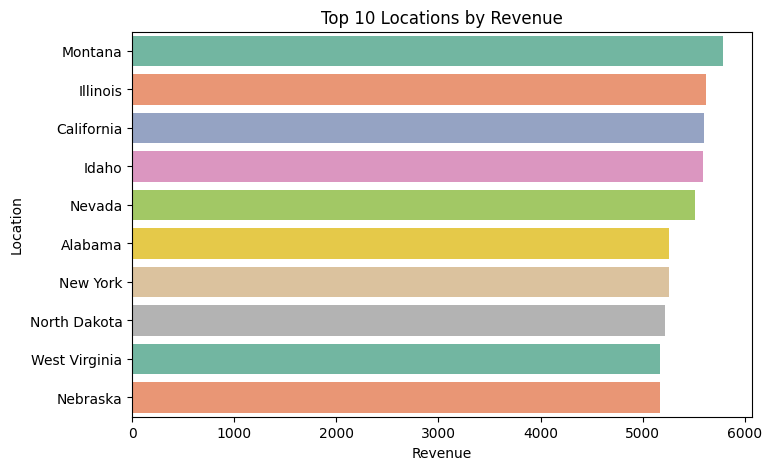

In [77]:
query = """
SELECT Location,
SUM([Purchase Amount (USD)]) AS Revenue
FROM shopping_trends
GROUP BY Location
ORDER BY Revenue DESC
LIMIT 10
"""

df_loc = pd.read_sql(query, conn)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_loc,
    x="Revenue",
    y="Location",
    palette="Set2",
    hue="Location"
)

plt.title("Top 10 Locations by Revenue")
plt.show()

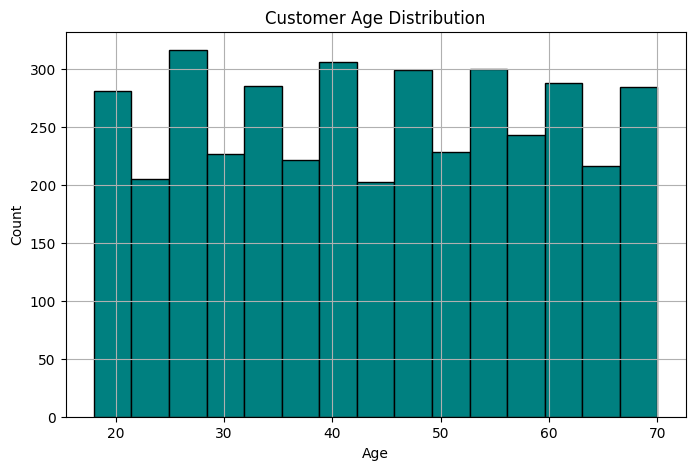

In [78]:
plt.figure(figsize=(8,5))
df["Age"].hist(
    bins=15,
    color="teal",
    edgecolor="black"
)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

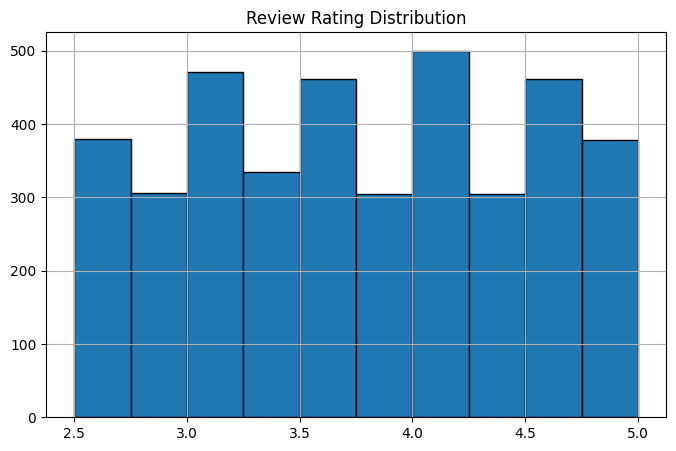

In [79]:
plt.figure(figsize=(8,5))
df["Review Rating"].hist(bins=10,edgecolor="black")
plt.title("Review Rating Distribution")
plt.show()

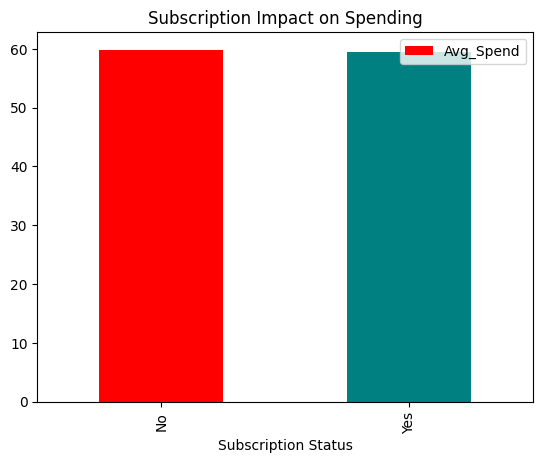

In [80]:
query = """
SELECT [Subscription Status],
AVG([Purchase Amount (USD)]) AS Avg_Spend
FROM shopping_trends
GROUP BY [Subscription Status]
"""

df_sub = pd.read_sql(query, conn)

df_sub.plot(
    x="Subscription Status",
    y="Avg_Spend",
    kind="bar",
    color=["red", "teal"],
    title="Subscription Impact on Spending"
)
plt.show()

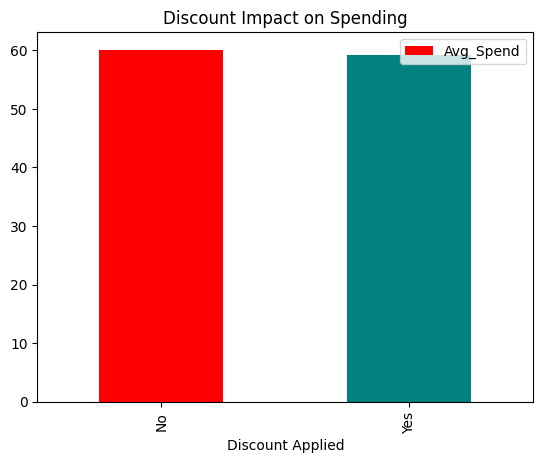

In [81]:
query = """
SELECT [Discount Applied],
AVG([Purchase Amount (USD)]) AS Avg_Spend
FROM shopping_trends
GROUP BY [Discount Applied]
"""

df_disc = pd.read_sql(query, conn)

df_disc.plot(
    x="Discount Applied",
    y="Avg_Spend",
    kind="bar",
    color=["red", "teal"],    
    title="Discount Impact on Spending"
)
plt.show()

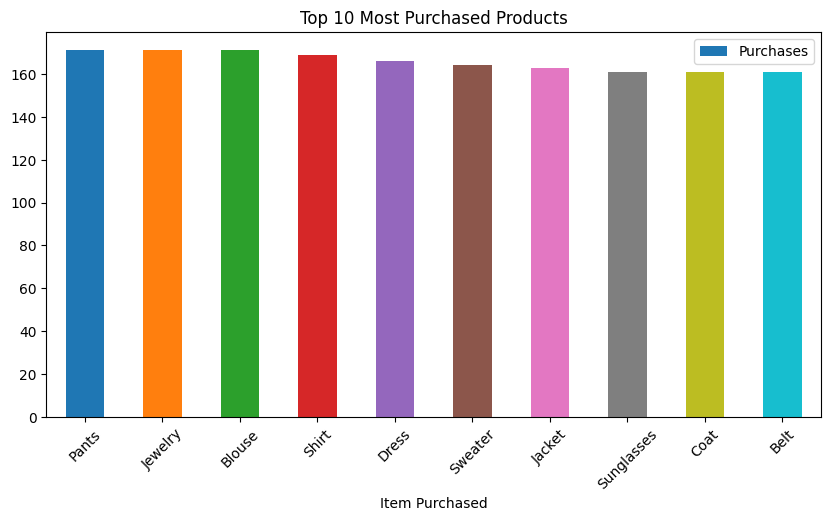

In [82]:
query = """
SELECT [Item Purchased],
COUNT(*) AS Purchases
FROM shopping_trends
GROUP BY [Item Purchased]
ORDER BY Purchases DESC
LIMIT 10
"""

df_item = pd.read_sql(query, conn)

df_item.plot(
    x="Item Purchased",
    y="Purchases",
    kind="bar",
    figsize=(10,5),
    color=plt.cm.tab10(range(len(df_item))),
    title="Top 10 Most Purchased Products"
)
plt.xticks(rotation=45)
plt.show()

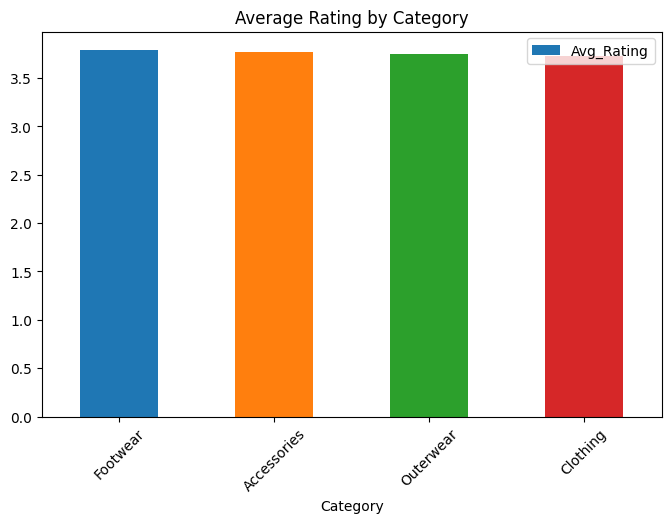

In [83]:
query = """
SELECT Category,
AVG([Review Rating]) AS Avg_Rating
FROM shopping_trends
GROUP BY Category
ORDER BY Avg_Rating DESC
"""

df_rating = pd.read_sql(query, conn)
df_rating.plot(
    x="Category",
    y="Avg_Rating",
    kind="bar",
    figsize=(8,5),
    color=plt.cm.tab10(range(len(df_rating))),
    title="Average Rating by Category"
)

plt.xticks(rotation=45)
plt.show()

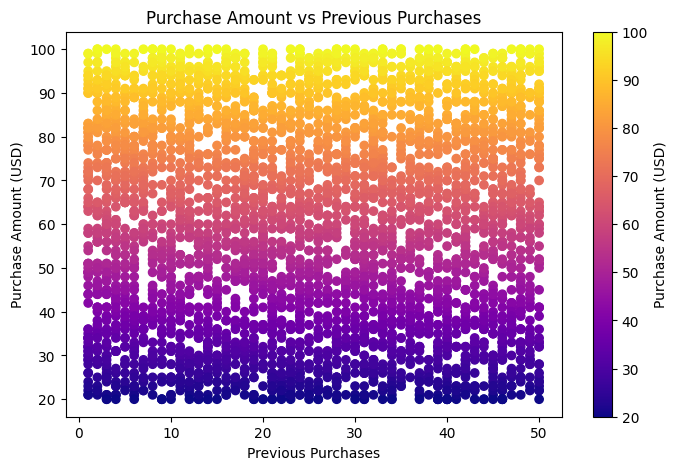

In [84]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Previous Purchases"],
    df["Purchase Amount (USD)"],
    c=df["Purchase Amount (USD)"],
    cmap="plasma"
)
plt.colorbar(label="Purchase Amount (USD)")
plt.title("Purchase Amount vs Previous Purchases")
plt.xlabel("Previous Purchases")
plt.ylabel("Purchase Amount (USD)")
plt.show()